## Population-Based Structural Health Monitoring (PBSHM)

### Objective
Detect whether a structure is damaged using measurement-like features and graph structure.

## Dataset Overview
- 50 structures
- Each has 4–8 storeys
- Structure Features:
  - Structure id (`structure_id`)
  - Number of Storeys (`n_storeys`)
  - Edges (`edges`)
  - Node Features (`n_features`)
  - Feature Names (`feature_names`)

- Node features:
  - Storey (`storey`)
  - height (`height_m`)
  - dominant modal frequency (`dominant_modal_frequency_Hz`)

- Available Structure Labels:
  - Structure id (`structure_id`)
  - Damaged (`damaged`)
  - Damage Storey (`damage_storey`)

In [39]:
"""
Imprting necessary libraries and setting up the environment 
for data analysis and visualization.
"""
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
from sklearn.cluster import KMeans
plt.style.use('seaborn')


### Task1: Population Exploration (EDA)
Characterize the dataset and explain the variation across the population.

- Visualize the distribution of structure sizes and geometry
- Explore the starter population graph
- Inspect the provided measurement-like node features
- Propose which raw or derived features might be damage-sensitive


In [2]:
#-//--------- Data Loading and Preprocessing ---------//-

with open('structures_measurements.json') as f:
    structures = json.load(f)

labels = pd.read_csv('structure_labels.csv')

# Load population graph
edges = pd.read_csv("population_edges_geometry.csv")
weights = pd.read_csv("population_edge_weights_geometry.csv")

# Flatten node data
node_properties = []
for structure in structures:
    structure_id = structure['structure_id']
    n_storeys = structure['n_storeys']
    
    for node in structure['node_features']:
        node_propert = node.copy()
        node_propert['structure_id'] = structure_id
        node_propert['n_storeys'] = n_storeys
        node_properties.append(node_propert)

# Create DataFrame from node properties
nodes_df = pd.DataFrame(node_properties)

# Merge labels with node properties
nodes_df = nodes_df.merge(labels, on='structure_id')

#--//--------- Structure-Level Feature Extraction ---------//-
# Structure-level dataframe
structure_property = []
for structure in structures:
    structure_id = structure['structure_id']
    structure_property.append({
        'structure_id': structure_id,
        'n_storeys': structure['n_storeys'],
        'total_height': sum(n['height_m'] for n in structure['node_features']),
        'damaged': labels.loc[labels.structure_id == structure_id, 'damaged'].values[0]
    })

# Create DataFrame from structure properties
structure_df = pd.DataFrame(structure_property)


#nodes_df.head()
structure_df.head()

,structure_id,n_storeys,total_height,damaged
0,0,6,24.905,0
1,1,5,19.219,0
2,2,8,32.077,0
3,3,6,22.181,1
4,4,7,29.248,1


In [3]:
nodes_df.head()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey
0,0,3.532,2.66633,0,6,0,NaN
1,1,4.938,8.06059,0,6,0,NaN
2,2,4.558,4.46783,0,6,0,NaN
3,3,4.434,2.66633,0,6,0,NaN
4,4,3.899,5.19604,0,6,0,NaN


#### Distribution of Structure Sizes

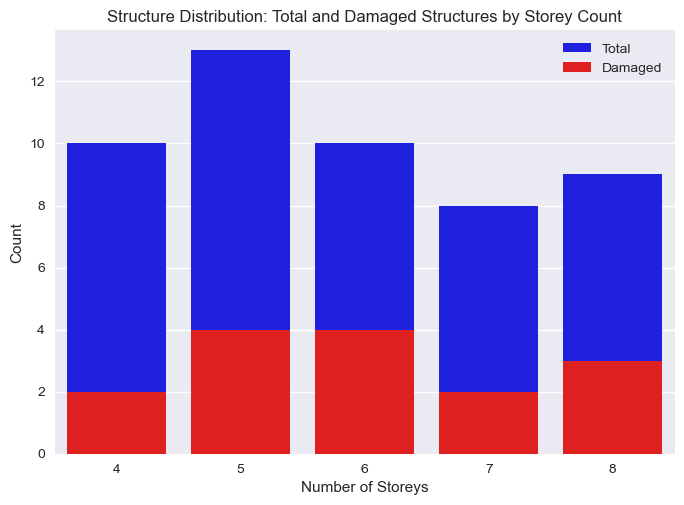

In [4]:
# Structure-level unique data
unique_structure_df = nodes_df[['structure_id', 'n_storeys', 'damaged']].drop_duplicates()

# Total structure count per group
total_counts = unique_structure_df['n_storeys']

# Damaged only
damaged_counts = unique_structure_df[unique_structure_df['damaged'] == 1]['n_storeys']

# Plot
sns.countplot(x=total_counts, color='blue', label='Total')
sns.countplot(x=damaged_counts, color='red', label='Damaged')

plt.title("Structure Distribution: Total and Damaged Structures by Storey Count")
plt.xlabel("Number of Storeys")
plt.ylabel("Count")
plt.legend()
plt.show()

- Hights are relatively well distributed across each story in a Structure group

#### Starter population graph

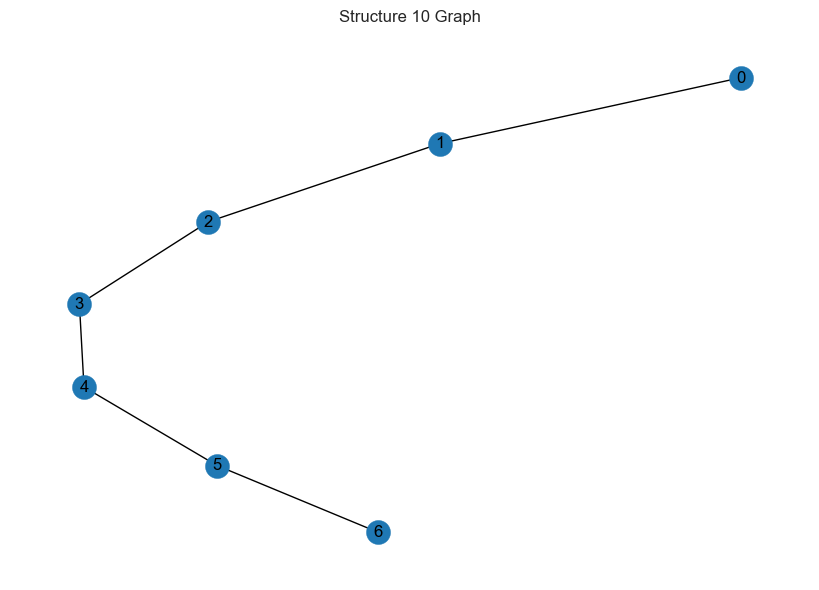

In [5]:
# Structure-level graph visualization
sample_structure = structures[10]

sample_structure_graph = nx.Graph()
sample_structure_graph.add_edges_from(sample_structure['edges'])

nx.draw(sample_structure_graph, with_labels=True)
plt.title(f"Structure {sample_structure['structure_id']} Graph")
plt.show()

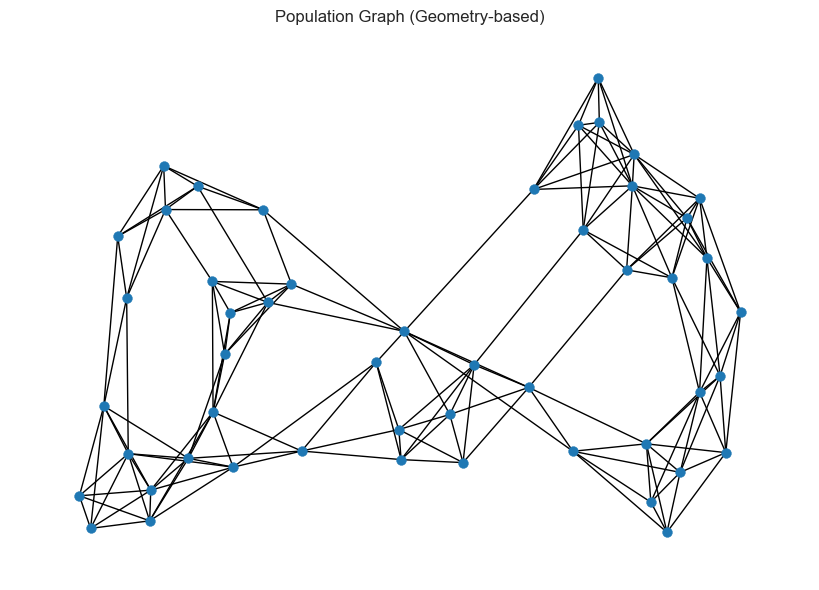

In [6]:
# Population graph visualization
structure_pop_graph = nx.from_pandas_edgelist(edges, 'source', 'target')

nx.draw(structure_pop_graph, node_size=50)
plt.title("Population Graph (Geometry-based)")

plt.show()

#### Inspection of Node features Measurement



In [7]:
nodes_df.head()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey
0,0,3.532,2.66633,0,6,0,NaN
1,1,4.938,8.06059,0,6,0,NaN
2,2,4.558,4.46783,0,6,0,NaN
3,3,4.434,2.66633,0,6,0,NaN
4,4,3.899,5.19604,0,6,0,NaN


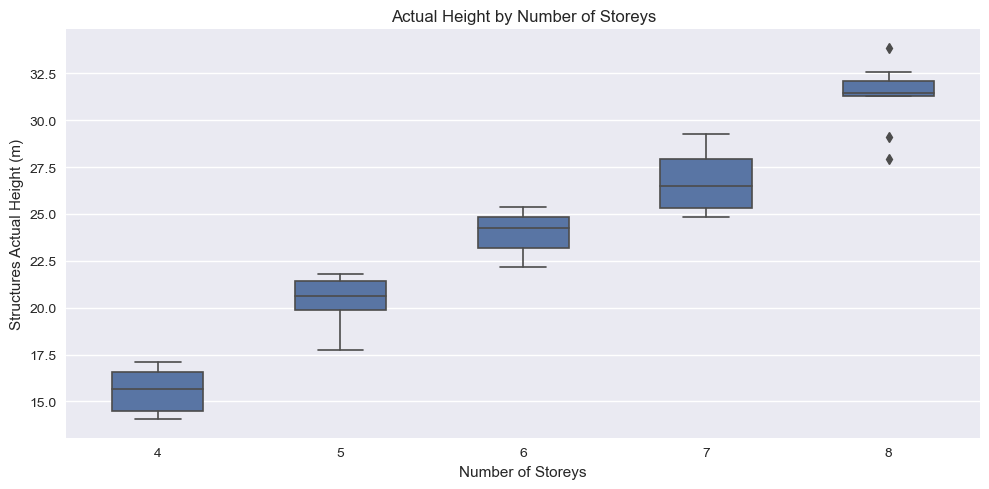

In [8]:
# Boxplot of Structure total height by number of storeys
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=structure_df,
    x='n_storeys',
    y='total_height',
    color='#4C72B0',   # clean, professional blue
    width=0.5,
    linewidth=1.2
)

plt.title("Actual Height by Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Structures Actual Height (m)")
plt.tight_layout()
plt.show()

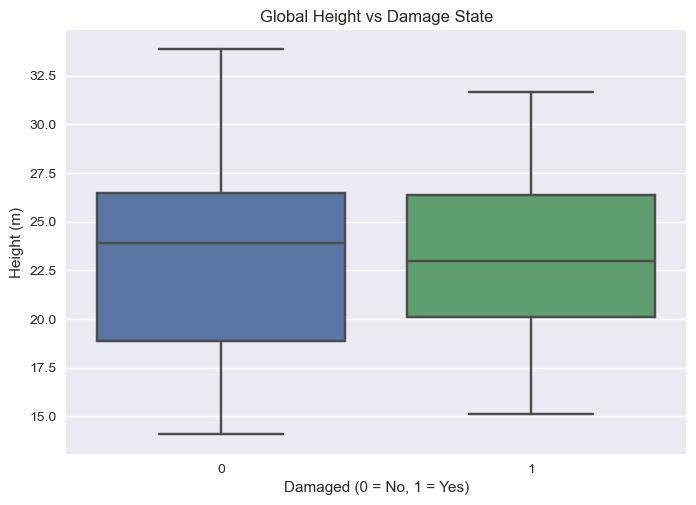

In [9]:
sns.boxplot(
    data=structure_df,
    x='damaged',
    y='total_height',
)
plt.title("Global Height vs Damage State")
plt.xlabel("Damaged (0 = No, 1 = Yes)")
plt.ylabel("Height (m)")
plt.show()

Observation: Structure Hight correlates strongly with Number of Stories, thought slight local variations in the node level

### Frequency Analysis

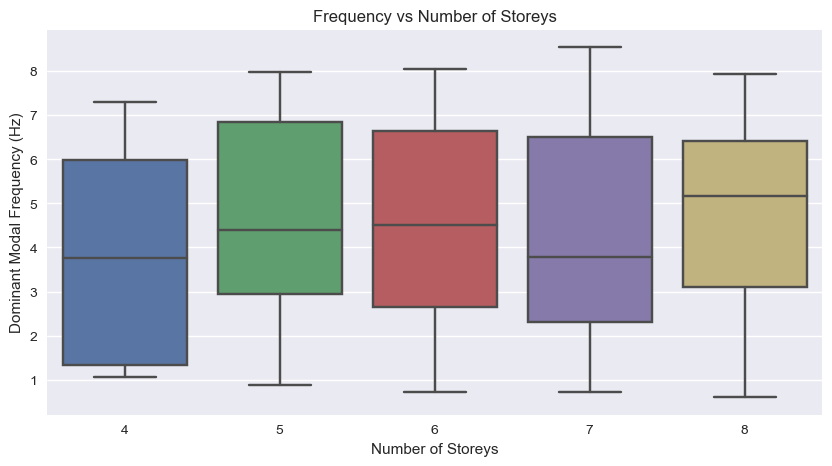

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=nodes_df,
    x='n_storeys',
    y='dominant_modal_frequency_Hz'
    #hue='damaged',
   
)
plt.title("Frequency vs Number of Storeys")
plt.xlabel("Number of Storeys")
plt.ylabel("Dominant Modal Frequency (Hz)") 
plt.show()

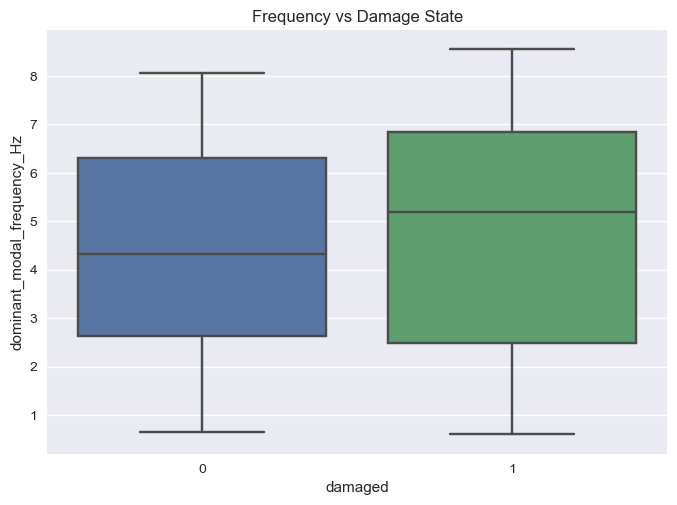

In [11]:
sns.boxplot(
    data=nodes_df,
    x='damaged',
    y='dominant_modal_frequency_Hz'
)
plt.title("Frequency vs Damage State")
plt.show()

Observation: 
- Significant overlap between classes
But: *Damaged structures show slightly more spread values*

Key takeaway:
Raw frequency alone is not sufficient, but still informative

- 

#### Feature Engineering Frequency Data (A dynamic Variable)

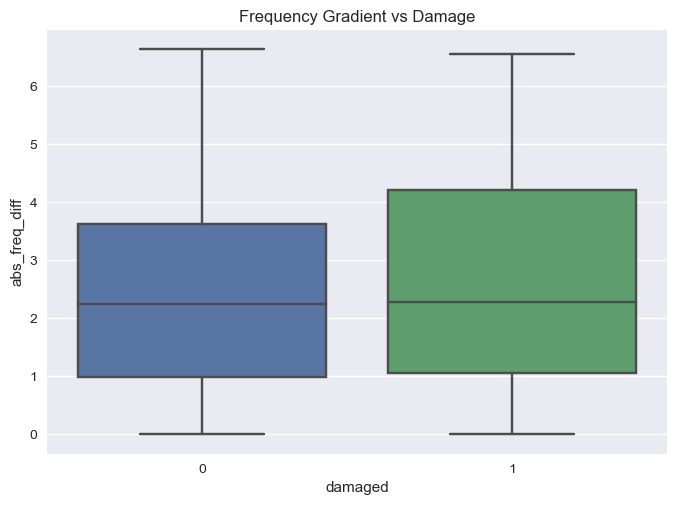

In [12]:
nodes_df['freq_diff'] = nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'].diff()
nodes_df['abs_freq_diff'] = nodes_df['freq_diff'].abs() # Intrested in Magnitude of change not direction

sns.boxplot(data=nodes_df, x='damaged', y='abs_freq_diff')
plt.title("Frequency Gradient vs Damage")
plt.show()

In [13]:
nodes_df.head()

,storey,height_m,dominant_modal_frequency_Hz,structure_id,n_storeys,damaged,damage_storey,freq_diff,abs_freq_diff
0,0,3.532,2.66633,0,6,0,NaN,NaN,NaN
1,1,4.938,8.06059,0,6,0,NaN,5.39426,5.39426
2,2,4.558,4.46783,0,6,0,NaN,-3.59276,3.59276
3,3,4.434,2.66633,0,6,0,NaN,-1.80150,1.80150
4,4,3.899,5.19604,0,6,0,NaN,2.52971,2.52971


### Frequency Variance Analysis

In [ ]:
structure_df.head()

,structure_id,n_storeys,total_height,damaged
0,0,6,24.905,0
1,1,5,19.219,0
2,2,8,32.077,0
3,3,6,22.181,1
4,4,7,29.248,1


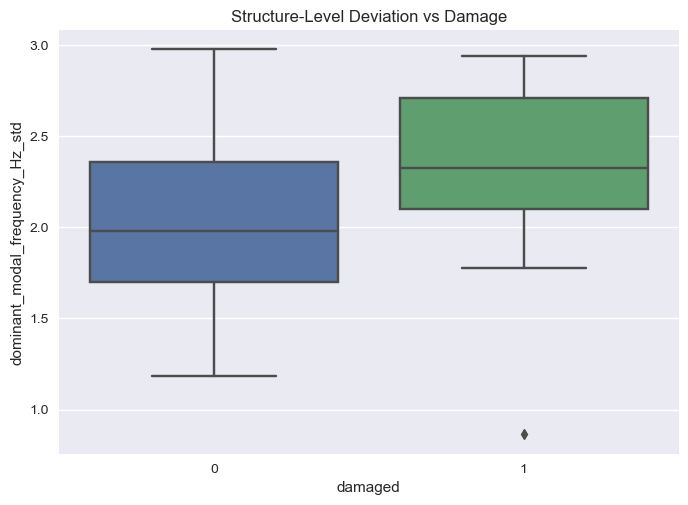

In [15]:
# copy of sturcture datafram
structure_copy_df = structure_df


structure_df = nodes_df.groupby('structure_id').agg({
    'dominant_modal_frequency_Hz': ['mean', 'std'],
    'n_storeys': 'first',
    'height_m': 'sum',
    
})

structure_df.columns = ['_'.join(col) for col in structure_df.columns]
structure_df = structure_df.reset_index()
structure_df = structure_df.merge(labels, on='structure_id')


sns.boxplot(data=structure_df, x='damaged', y='dominant_modal_frequency_Hz_std')
plt.title("Structure-Level Deviation vs Damage")
plt.show()

In [16]:
structure_df.head()

,structure_id,dominant_modal_frequency_Hz_mean,dominant_modal_frequency_Hz_std,n_storeys_first,height_m_sum,damaged,damage_storey
0,0,3.977460,2.525202,6,24.905,0,NaN
1,1,5.345074,2.019452,5,19.219,0,NaN
2,2,5.263772,1.184323,8,32.077,0,NaN
3,3,5.355862,2.556491,6,22.181,1,0.0
4,4,4.615880,2.340717,7,29.248,1,4.0


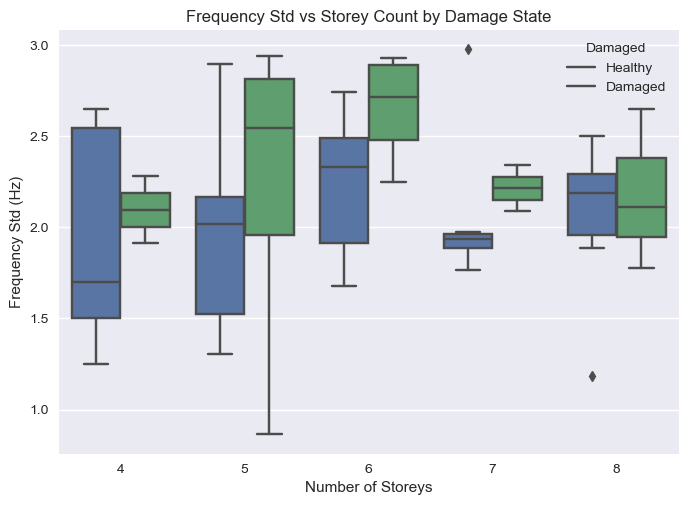

In [17]:
# Plot: 5 pairs of boxplots (one per storey group)
sns.boxplot(
    data=structure_df,
    x='n_storeys_first',                          # groups (4–8)
    y='dominant_modal_frequency_Hz_std',    # feature
    hue='damaged'                           # pairs (0 vs 1)
)

plt.title("Frequency Std vs Storey Count by Damage State")
plt.xlabel("Number of Storeys")
plt.ylabel("Frequency Std (Hz)")
plt.legend(title="Damaged", labels=["Healthy", "Damaged"])
plt.show()

## Interpretation: Frequency Variability vs Structure Size

The standard deviation of modal frequency was analyzed across structures of different sizes and damage states.

### Key Observations

- Damaged structures generally exhibit higher frequency variability, particularly for 5,6 and 7 storey structures.
- This indicates that damage introduces irregularities in the structural dynamic response.
- The separation between damaged and healthy structures is most pronounced in medium-sized structures.

### Physical Intuition

- If a structure experiences varring frequency (More than one mode shape), there is more tendency of sharing as it tends to woble or bend which can occure due to dammage resulting in a localized stiffness reduction.
- This disrupts the smooth distribution of modal frequencies across storeys.
- As a result, damaged structures show increased variability (higher standard deviation).

### Size-Dependent Behavior

- **Small structures (4 storeys):**
  - Limited resolution → weak damage signal

- **Medium structures (5–7 storeys):**
  - Optimal balance → strongest detectability

- **Large structures (8 storeys):**
  - Increased natural variability → damage signal becomes less distinct

### Conclusion

Frequency variability is a strong damage-sensitive feature, particularly for medium-sized structures.

This suggests that:
- Damage detection performance may depend on structure size which can be accounted for using number of stories
- Models should account for structural scale when learning damage patterns

#### Since hight are fixed variable, it doesnt make sense to analyse Std

In [18]:
structure_df.head()

,structure_id,dominant_modal_frequency_Hz_mean,dominant_modal_frequency_Hz_std,n_storeys_first,height_m_sum,damaged,damage_storey
0,0,3.977460,2.525202,6,24.905,0,NaN
1,1,5.345074,2.019452,5,19.219,0,NaN
2,2,5.263772,1.184323,8,32.077,0,NaN
3,3,5.355862,2.556491,6,22.181,1,0.0
4,4,4.615880,2.340717,7,29.248,1,4.0


## Distribution of Structure Sizes and Geometry

### Key Observations

   - Total height increases consistently with the number of storeys
   - Each storey group forms a distinct cluster, indicating a near-linear relationship
   - Structures with the same number of storeys exhibit similar total heights
   - This sugest geometric simmilarities across the Population groups (Good for PBSHM)

   - The distributions of total height for damaged and undamaged structures almost overlap completely. Very little visible shift in median or spread is observed, some variation exists due to differences in individual storey heights

### Insight from the EDA

- Structural geometry is primarily determined by the number of storeys
- The dataset exhibits consistent geometric properties across the population
- Though the structural heigth data is not directly damage-sensitive, but by physics intuition it:
  - Influences stiffness and mass distribution
  - Helps categories structures in a population.


# Task 2 - Simple structure-level baseline
Build a simple baseline for damage detection using fixed-length summaries of each structure.

Examples include:

- logistic regression
- Random forest
- support vector machine
- A small MLP
Because structures have different numbers of nodes, you will need to design a sensible summary representation.

Report appropriate metrics such as accuracy, F1, and ROC-AUC using cross-validation.

In [19]:
# Move structure_id from the index back to a column
structure_df = structure_df.reset_index()

structure_bl_df = structure_df[[
    'structure_id', 
    'dominant_modal_frequency_Hz_std', 
    'n_storeys_first',
    'damaged',
    'height_m_sum'
]]



#### Based  on the observations in the frequency analysis, we will be using *Random Forest* as our baseline model:

- It Feature Interactions: The "damage sensitivity" of a frequency shift is observed not to be universal accross the number of stories. A 2Hz shift in an 8-storey building means something very different than a 2Hz shift in a 5-storey building. Random Forest is expected to captures these non-linear interactions between n_storeys and frequency_std automatically.

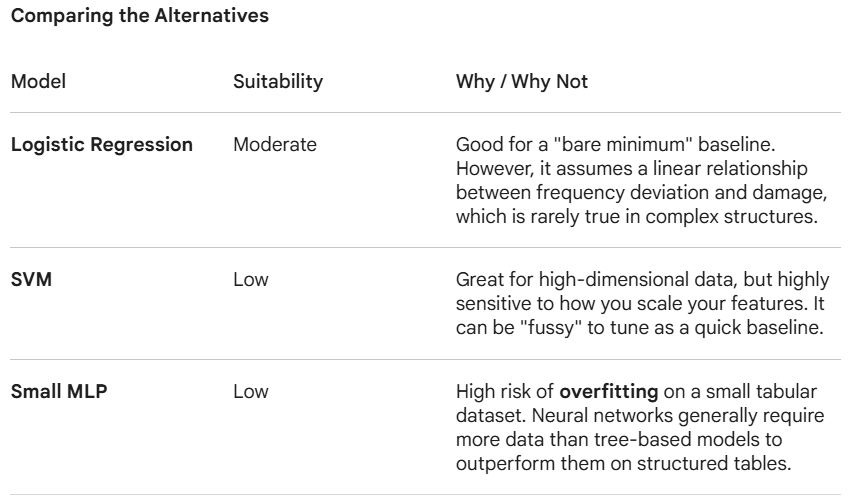

In [20]:
structure_bl_df.head()

,structure_id,dominant_modal_frequency_Hz_std,n_storeys_first,damaged,height_m_sum
0,0,2.525202,6,0,24.905
1,1,2.019452,5,0,19.219
2,2,1.184323,8,0,32.077
3,3,2.556491,6,1,22.181
4,4,2.340717,7,1,29.248


In [21]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Initialize the MinMaxScaler
scaler = MinMaxScaler()

# 2. Select the columns to be normalized
# We'll normalize the frequency and the total height
cols_to_normalize = ['dominant_modal_frequency_Hz_std', 'height_m_sum']

# 3. Apply the transformation
normalized_data = scaler.fit_transform(structure_bl_df[cols_to_normalize])

# 4. Create the final dataframe with your requested names
# We create new columns for normalized values and pull the rest from the original
structure_norm_df = pd.DataFrame(normalized_data, columns=['Freq_norm', 'Height_norm'], index=structure_bl_df.index)

# Add the remaining original columns
structure_norm_df['n_storeys'] = structure_bl_df['n_storeys_first']
structure_norm_df['damaged'] = structure_bl_df['damaged']
structure_norm_df['structure_id'] = structure_bl_df['structure_id']

# 5. Reorder columns to match your exact request
structure_norm_df = structure_norm_df[['Freq_norm', 'Height_norm', 'n_storeys', 'damaged', 'structure_id']]

structure_norm_df.head()

,Freq_norm,Height_norm,n_storeys,damaged,structure_id
0,0.786729,0.547994,6,0,0
1,0.547231,0.260736,5,0,1
2,0.151755,0.910326,8,0,2
3,0.801546,0.410377,6,1,3
4,0.699366,0.767404,7,1,4


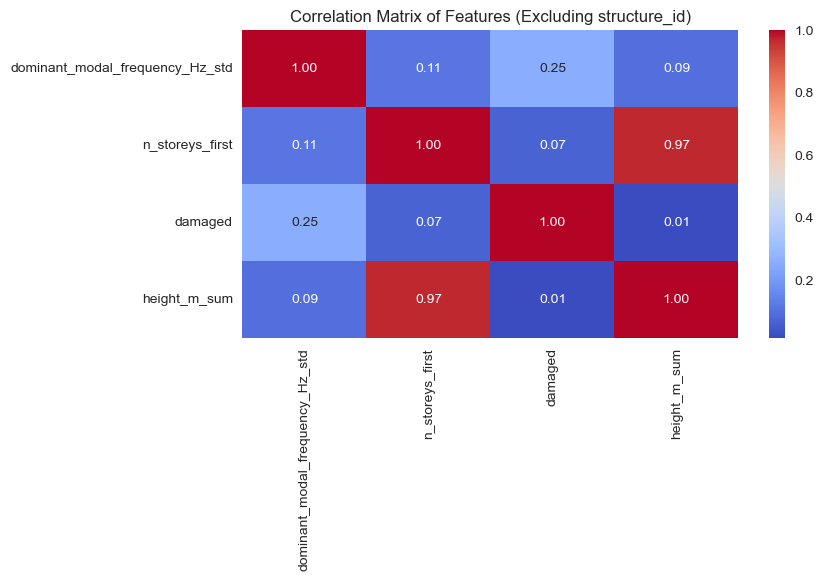

In [22]:
# Compute the correlation matrix without 'structure_id'
correlation_matrix = structure_bl_df.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Features (Excluding structure_id)")
plt.show()

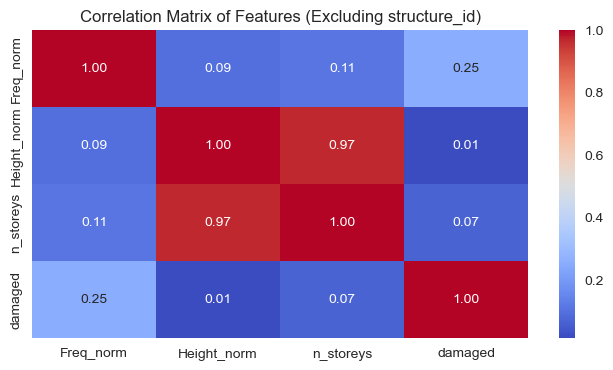

In [23]:
# Compute the correlation matrix without 'structure_id'
correlation_matrix = structure_norm_df.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Features (Excluding structure_id)")
plt.show()



# baseline Model

Using Cross Validation

In [24]:
# ── Features & Target ─────────────────────────────────────────────
X = structure_norm_df.drop(columns=['structure_id', 'damaged', 'Height_norm'])
y = structure_norm_df['damaged']

# ── Model ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=50
)

# ── Cross-Validation ──────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# ── Train final model on full data ─────────────────────────────────
rf.fit(X, y)

# ── Results ───────────────────────────────────────────────────────
print("Accuracy:", scores['test_accuracy'].mean())
print("F1 Score:", scores['test_f1'].mean())
print("ROC-AUC:", scores['test_roc_auc'].mean())

# rf is now your trained model ready for feature importance

Accuracy: 0.6
F1 Score: 0.4
ROC-AUC: 0.5523809523809524


In [25]:
# # 1. Get predictions for the test set
# y_pred = rf.predict(X[5:11])
# results_df = X[5:11].copy()

# # 2. Add the original structure_id back from the main dataframe
# # This works because X_test still knows its original row index
# results_df['structure_id'] = structure_bl_df.loc[X_test.index, 'structure_id']

# # 3. Add the actual labels and the model's prediction
# y_test = y[5:11]
# results_df['actual_damage'] = y[5:11]
# results_df['predicted_damage'] = y_pred
# results_df.head(6)


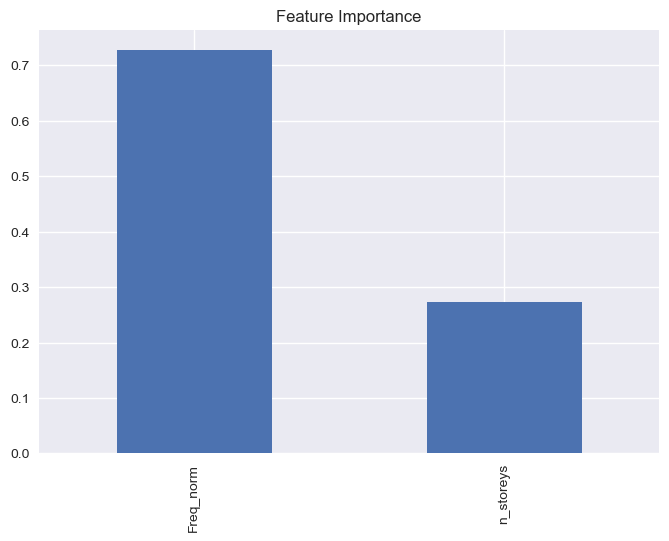

In [26]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [27]:
# ── Features & Target ─────────────────────────────────────────────
X = structure_norm_df.drop(columns=['structure_id', 'damaged', 'Height_norm'])
y = structure_norm_df['damaged']

# ── Model ─────────────────────────────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=50
)

# ── Cross-Validation ──────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

scores = cross_validate(
    lr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# ── Train final model ─────────────────────────────────────────────
lr.fit(X, y)

# ── Results ───────────────────────────────────────────────────────
print("Accuracy:", scores['test_accuracy'].mean())
print("F1 Score:", scores['test_f1'].mean())
print("ROC-AUC:", scores['test_roc_auc'].mean())

# lr is your trained model

Accuracy: 0.62
F1 Score: 0.5271428571428571
ROC-AUC: 0.6761904761904762


# Task 3

In [28]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score


# ── Features & Target ─────────────────────────────────────────────
X = structure_norm_df.drop(columns=['structure_id', 'damaged', 'Height_norm'])
y = structure_norm_df['damaged']

# ── Cross-validation setup ────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

acc_scores, f1_scores, roc_scores = [], [], []

# ── CV Loop ──────────────────────────────────────────────────────
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    # Train only on training data (unsupervised)
    iso = IsolationForest(
        n_estimators=100,
        contamination=0.3,  # matches ~30% damaged
        random_state=50
    )
    
    iso.fit(X_train)

    # Predict anomalies (-1 = anomaly → map to 1)
    y_pred = iso.predict(X_test)
    y_pred = np.where(y_pred == -1, 1, 0)

    # Scores
    acc_scores.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Use anomaly score for ROC
    scores = -iso.decision_function(X_test)
    roc_scores.append(roc_auc_score(y_test, scores))

# ── Results ───────────────────────────────────────────────────────
print("Accuracy:", np.mean(acc_scores))
print("F1 Score:", np.mean(f1_scores))
print("ROC-AUC:", np.mean(roc_scores))

# ── Train final model ─────────────────────────────────────────────
iso.fit(X)

c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Accuracy: 0.54
F1 Score: 0.4158730158730159
ROC-AUC: 0.5619047619047619


c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


IsolationForest(contamination=0.3, random_state=50)

In [29]:
structure_norm_df['n_storeys'].unique()

array([6, 5, 8, 7, 4], dtype=int64)

In [30]:
structure_norm_df.head()

,Freq_norm,Height_norm,n_storeys,damaged,structure_id
0,0.786729,0.547994,6,0,0
1,0.547231,0.260736,5,0,1
2,0.151755,0.910326,8,0,2
3,0.801546,0.410377,6,1,3
4,0.699366,0.767404,7,1,4


In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, precision_score, recall_score, f1_score

# --- 1. DATA SPLITTING ---
# We split the 50 points into 30 for training and 20 for reporting.
# We include 'damage' in the split only so we can evaluate the test set later.
train_df, test_df = train_test_split(structure_norm_df, test_size=0.4, random_state=42)

features = ['Freq_norm', 'n_storeys']
X_train_raw = train_df[features]
X_test_raw = test_df[features]
y_test = test_df['damaged'].values # Ground truth for reporting only

# --- 2. COLUMN-WISE SCALING ---
scaler = StandardScaler()
# We fit the scaler ONLY on training data to avoid data leakage
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- 3. MODEL TRAINING (UNSUPERVISED) ---
# PCA
pca = PCA(n_components=1)
pca.fit(X_train) # Learning the 'normal' axis from the 30-point training slab

# k-NN
knn = NearestNeighbors(n_neighbors=3) # Smaller k because dataset is small
knn.fit(X_train) # Building the reference neighborhood map

# --- 4. SCORING THE UNSEEN TEST DATA ---
# PCA scores (Reconstruction Error)
X_test_pca_repro = pca.inverse_transform(pca.transform(X_test))
pca_test_scores = np.mean((X_test - X_test_pca_repro) ** 2, axis=1)

# k-NN scores (Distance to neighbors)
distances, _ = knn.kneighbors(X_test)
knn_test_scores = distances.mean(axis=1)

# --- 5. REPORTING ---
def report_unseen_performance(name, scores, y_true):
    # Using the known 30% anomaly rate as the threshold trigger
    threshold = np.percentile(scores, 70)
    preds = (scores > threshold).astype(int)
   
    pr_auc = auc(*precision_recall_curve(y_true, scores)[1::-1])
   
    print(f"--- {name} Performance on Unseen Data (N=20) ---")
    print(f"PR-AUC: {pr_auc:.3f}")
    print(f"F1-Score: {f1_score(y_true, preds):.3f}")
    print(f"Precision: {precision_score(y_true, preds):.3f}")
    print(f"Recall: {recall_score(y_true, preds):.3f}\n")

report_unseen_performance("Unsupervised PCA", pca_test_scores, y_test)
report_unseen_performance("Unsupervised k-NN", knn_test_scores, y_test)

--- Unsupervised PCA Performance on Unseen Data (N=20) ---
PR-AUC: 0.597
F1-Score: 0.375
Precision: 0.500
Recall: 0.300

--- Unsupervised k-NN Performance on Unseen Data (N=20) ---
PR-AUC: 0.739
F1-Score: 0.500
Precision: 0.667
Recall: 0.400



c:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


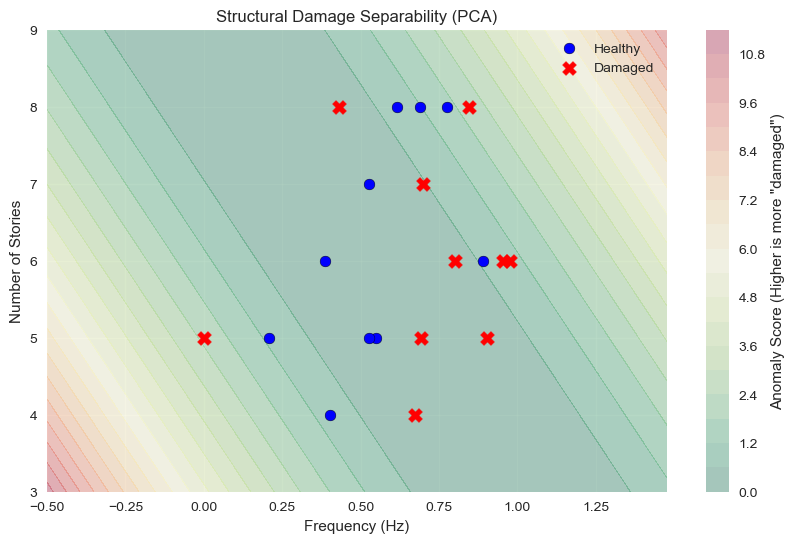

In [32]:


def visualize_separability(model, scaler, df, features, model_type="PCA"):
    # 1. Create a grid for the background "Decision Surface"
    x_min, x_max = df[features[0]].min() - 0.5, df[features[0]].max() + 0.5
    y_min, y_max = df[features[1]].min() - 1, df[features[1]].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
   
    # 2. Scale the grid to match model input
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_points)
   
    # 3. Get Anomaly Scores for the entire grid
    if model_type == "PCA":
        repro = model.inverse_transform(model.transform(grid_scaled))
        Z = np.mean((grid_scaled - repro) ** 2, axis=1)
    else: # k-NN
        distances, _ = model.kneighbors(grid_scaled)
        Z = distances.mean(axis=1)
   
    Z = Z.reshape(xx.shape)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
   
    # Plot the "Anomaly Terrain" (Lower score = more normal)
    contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.3)
    plt.colorbar(contour, label='Anomaly Score (Higher is more "damaged")')
   
    # Plot the actual buildings
    normal = df[df['damaged'] == 0]
    damaged = df[df['damaged'] == 1]
   
    plt.scatter(normal[features[0]], normal[features[1]], c='blue', label='Healthy', edgecolors='k', s=60)
    plt.scatter(damaged[features[0]], damaged[features[1]], c='red', label='Damaged', marker='X', s=100)

    plt.title(f"Structural Damage Separability ({model_type})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Number of Stories")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Execute for your k-NN model
visualize_separability(pca, scaler, test_df, features, model_type="PCA")

In [40]:


# ── Features & Target ─────────────────────────────────────────────
X = structure_bl_df.drop(columns=['structure_id', 'damaged'])
y = structure_bl_df['damaged']

# ── Cross-validation ──────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores, f1_scores, roc_scores = [], [], []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # K-Means (5 clusters = structure types)
    kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10,
    algorithm="elkan"
    )
    kmeans.fit(X_train)

    # Predict clusters for test set
    test_clusters = kmeans.predict(X_test)

    # Map clusters → labels using TRAIN data
    train_clusters = kmeans.predict(X_train)
    cluster_map = {}

    for c in np.unique(train_clusters):
        mask = train_clusters == c
        cluster_map[c] = y_train.iloc[mask].mode()[0]

    y_pred = np.array([cluster_map[c] for c in test_clusters])

    # Metrics
    acc_scores.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    # Distance to closest centroid as anomaly score
    distances = kmeans.transform(X_test).min(axis=1)
    roc_scores.append(roc_auc_score(y_test, distances))

# ── Results ───────────────────────────────────────────────────────
print("Accuracy:", np.mean(acc_scores))
print("F1 Score:", np.mean(f1_scores))
print("ROC-AUC:", np.mean(roc_scores))

AttributeError: 'NoneType' object has no attribute 'split'

In [54]:
structure_norm_df.head(10)

,Freq_norm,Height_norm,n_storeys,damaged,structure_id
0,0.786729,0.547994,6,0,0
1,0.547231,0.260736,5,0,1
2,0.151755,0.910326,8,0,2
3,0.801546,0.410377,6,1,3
4,0.699366,0.767404,7,1,4
5,0.844090,0.012984,4,0,5
6,0.401166,0.012630,4,0,6
7,0.616664,0.331565,5,0,7
8,0.976775,0.493180,6,1,8
9,0.638245,0.936546,8,0,9
